In [1]:
# Core libraries
!pip install pandas numpy matplotlib seaborn

# Time series models
!pip install statsmodels prophet

# Machine learning (optional for regression/classification)
!pip install scikit-learn xgboost

# Survival analysis (optional for churn)
!pip install lifelines

  Using cached prophet-1.2.1-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
Using cached prophet-1.2.1-py3-none-win_amd64.whl (12.1 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)

   ---------------------------------------- 0/2 [cmdstanpy]
   ---------------------------------------- 0/2 [cmdstanpy]
   ---------------------------------------- 0/2 [cmdstanpy]
   ---------------------------------------- 0/2 [cmdstanpy]
   ---------------------------------------- 0/2 [cmdstanpy]
   ---------------------------------------- 0/2 [cmdstanpy]
   ---------------------------------------- 0/2 [cmdstanpy]
   ---------------------------------------- 0/2 [cmdstanpy]
   -------------------- ------------------- 1/2 [prophet]
   -------------------- ------------------- 1/2 [prophet]
   -------------------- ------------------- 1/2 [prophet]
   -------------------- ------------------- 1/2 [prophet]
   -------------------- -------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


C:\Users\ZYadmin\AppData\Local\Temp\ipykernel_5824\1563886198.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_demand = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Quantity'].sum()


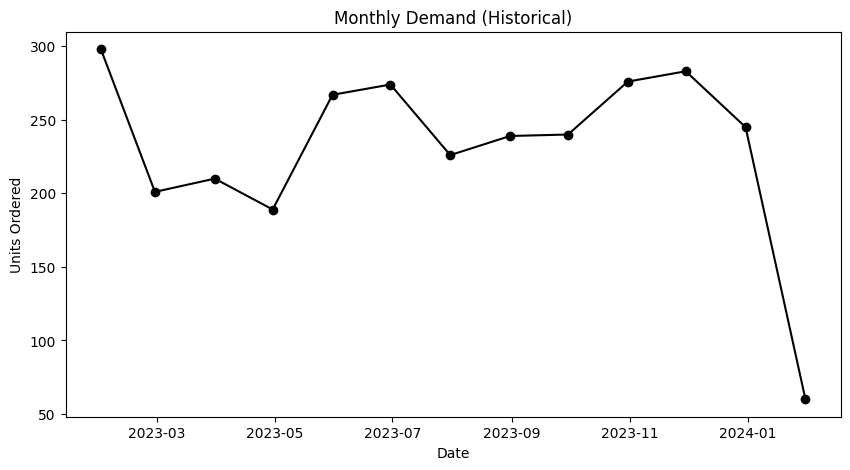

Order Date
2023-01-31    298
2023-02-28    201
2023-03-31    210
2023-04-30    189
2023-05-31    267
Freq: ME, Name: Quantity, dtype: int64

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("../Source data/Clean_ecom_data.xlsx")

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])

#print(df.head())

# Aggregate monthly demand
monthly_demand = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Quantity'].sum()

# Plot historical demand
plt.figure(figsize=(10,5))
plt.plot(monthly_demand, marker='o', color='black')
plt.title("Monthly Demand (Historical)")
plt.xlabel("Date")
plt.ylabel("Units Ordered")
plt.show()

monthly_demand.head()



# Time Series Forecasting
Goal: Forecast demand over time


Models:
- ARIMA / SARIMA → trend + seasonality
- Prophet → holidays, promotions
- ETS → smoothing for short‑term


c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /


            ARIMA_Forecast  SARIMA_Forecast
2024-02-29       17.139958            -37.0
2024-03-31       11.359425            -28.0
2024-04-30       10.579805            -49.0
2024-05-31       10.474657             29.0
2024-06-30       10.460476             36.0
2024-07-31       10.458563            -12.0


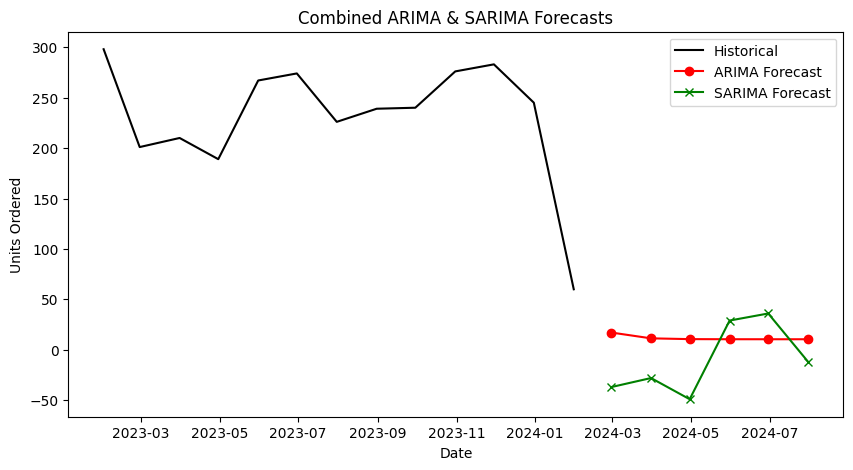

In [22]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# --- ARIMA ---
arima_model = ARIMA(monthly_demand, order=(1,1,1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=6)

# --- SARIMA ---
sarima_model = SARIMAX(monthly_demand, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()
sarima_forecast = sarima_fit.forecast(steps=6)

# --- Combine into one dataset ---
combined_df = pd.DataFrame({
    "ARIMA_Forecast": arima_forecast,
    "SARIMA_Forecast": sarima_forecast
})
print(combined_df)

# --- Graph ---
plt.figure(figsize=(10,5))
plt.plot(monthly_demand, label="Historical", color="black")
plt.plot(arima_forecast, label="ARIMA Forecast", color="red", marker='o')
plt.plot(sarima_forecast, label="SARIMA Forecast", color="green", marker='x')
plt.title("Combined ARIMA & SARIMA Forecasts")
plt.xlabel("Date")
plt.ylabel("Units Ordered")
plt.legend()
plt.show()

16:32:15 - cmdstanpy - INFO - Chain [1] start processing
16:32:47 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


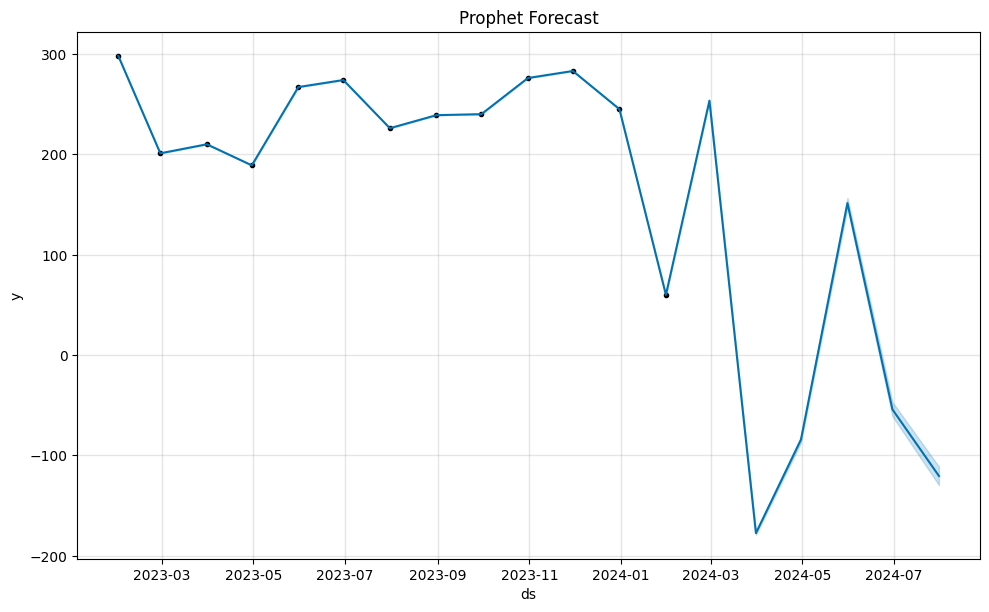

In [23]:
from prophet import Prophet

prophet_df = monthly_demand.reset_index()
prophet_df.columns = ['ds','y']

prophet_model = Prophet(yearly_seasonality=True)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=6, freq='M')
prophet_forecast = prophet_model.predict(future)

# Save dataset
prophet_out = prophet_forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(6)

# Graph
prophet_model.plot(prophet_forecast)
plt.title("Prophet Forecast")
plt.show()

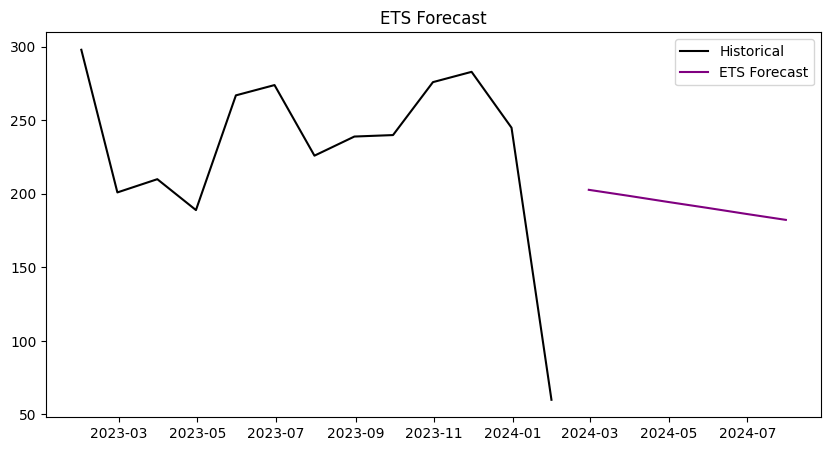

In [24]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# If you have <24 months, drop seasonality
ets_model = ExponentialSmoothing(monthly_demand, trend='add')
ets_fit = ets_model.fit()
ets_forecast = ets_fit.forecast(6)

# Save dataset
ets_df = ets_forecast.to_frame(name="ETS_Forecast")

# Graph
plt.figure(figsize=(10,5))
plt.plot(monthly_demand, label="Historical", color="black")
plt.plot(ets_forecast, label="ETS Forecast", color="purple")
plt.title("ETS Forecast")
plt.legend()
plt.show()

# Regression Prediction

## Linear Regression


   Actual  Predicted
0       5   3.006896
1       2   3.005496
2       1   3.006896
3       5   3.005496
4       3   3.015296


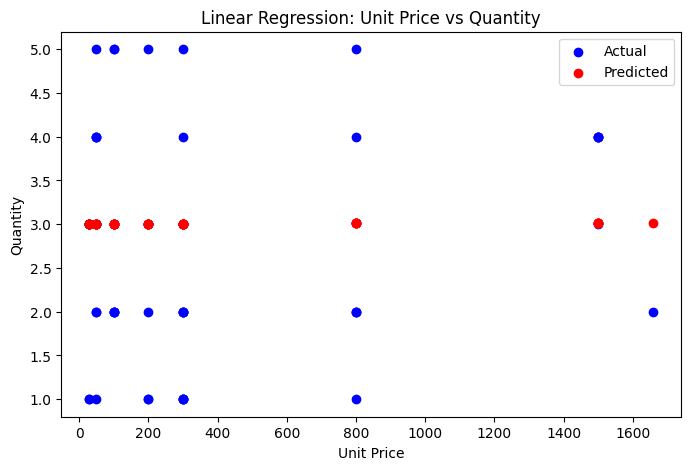

In [27]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Use only Unit Price as predictor
X_lin = df[['Unit Price']].fillna(0)
y_lin = df['Quantity']

lin_model = LinearRegression().fit(X_lin, y_lin)
lin_preds = lin_model.predict(X_lin)

lin_df = pd.DataFrame({"Actual": y_lin, "Predicted": lin_preds})
print(lin_df.head())

plt.figure(figsize=(8,5))
plt.scatter(X_lin['Unit Price'][:50], y_lin[:50], color="blue", label="Actual")
plt.scatter(X_lin['Unit Price'][:50], lin_preds[:50], color="red", label="Predicted")
plt.title("Linear Regression: Unit Price vs Quantity")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.legend()
plt.show()

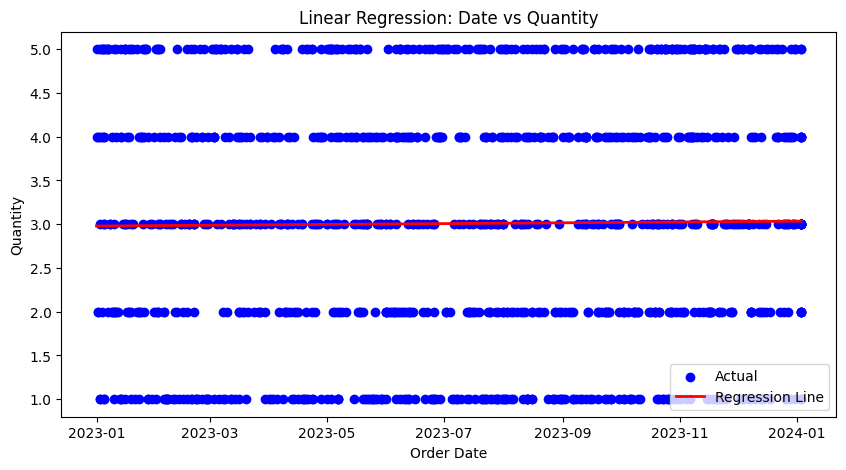

In [30]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Use Order Date as predictor
X_date = df[['Order Date']]
y_date = df['Quantity']

# Convert dates to numeric (ordinal)
X_date_num = X_date['Order Date'].map(lambda x: x.toordinal()).values.reshape(-1,1)

# Fit model
date_model = LinearRegression().fit(X_date_num, y_date)
y_pred_date = date_model.predict(X_date_num)

# Sort for clean line
sorted_idx = np.argsort(X_date_num.flatten())
X_sorted = X_date_num.flatten()[sorted_idx]
y_sorted = y_pred_date[sorted_idx]

# Graph
plt.figure(figsize=(10,5))
plt.scatter(df['Order Date'], y_date, color="blue", label="Actual")
plt.plot(df['Order Date'].iloc[sorted_idx], y_sorted, color="red", linewidth=2, label="Regression Line")
plt.title("Linear Regression: Date vs Quantity")
plt.xlabel("Order Date")
plt.ylabel("Quantity")
plt.legend()
plt.show()

c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


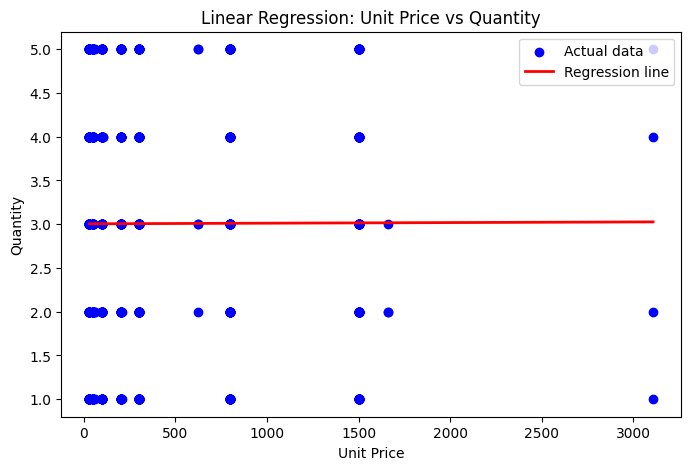

In [31]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Features and target
X = df[['Unit Price']].fillna(0)   # single predictor
y = df['Quantity']

# Fit model
lin_model = LinearRegression().fit(X, y)
y_pred = lin_model.predict(X)

# Sort values for a clean regression line
X_sorted = np.sort(X['Unit Price'])
y_line = lin_model.predict(X_sorted.reshape(-1,1))

# Scatter + regression line
plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X_sorted, y_line, color="red", linewidth=2, label="Regression line")
plt.title("Linear Regression: Unit Price vs Quantity")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.legend()
plt.show()

## Logistic Regression

  Order Date  Actual_Return  Predicted_Class  Predicted_Probability
0 2023-12-08              1                0               0.307966
1 2023-04-09              0                0               0.308023
2 2023-08-28              1                0               0.307990
3 2023-01-18              0                0               0.308042
4 2023-01-19              0                0               0.308042
5 2023-01-11              0                0               0.308044
6 2023-10-23              0                0               0.307977
7 2023-06-15              1                0               0.308008
8 2023-02-25              1                0               0.308033
9 2023-04-23              0                0               0.308020


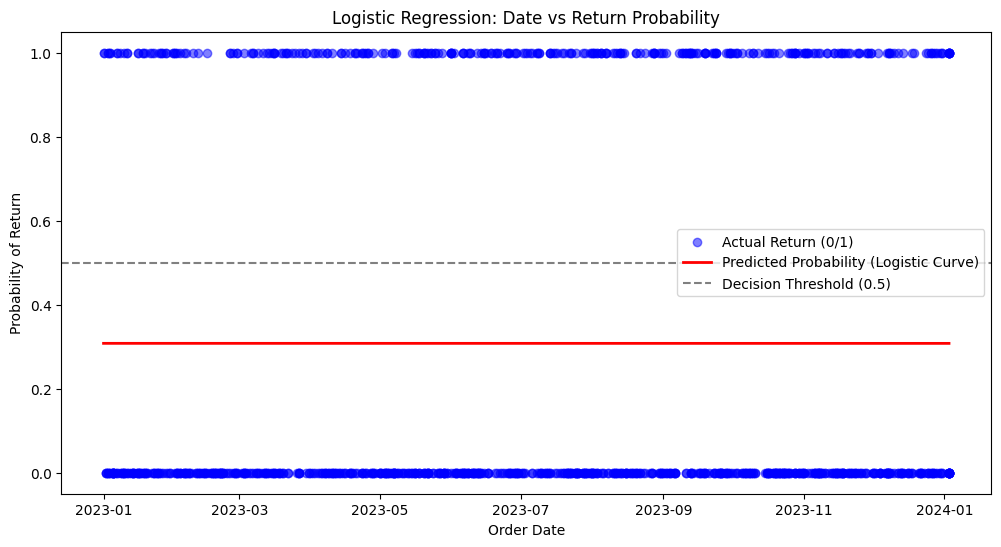

              precision    recall  f1-score   support

           0       0.69      1.00      0.82       692
           1       0.00      0.00      0.00       308

    accuracy                           0.69      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.48      0.69      0.57      1000



c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ZYadmin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Predictor = Date, Target = Return Status
X_date = df[['Order Date']]
y_return = df['Shipping Status'].apply(lambda x: 1 if x=="Returned" else 0)

# Convert dates to numeric (ordinal)
X_date_num = X_date['Order Date'].map(lambda x: x.toordinal()).values.reshape(-1,1)

# Fit logistic regression
log_model = LogisticRegression(max_iter=200).fit(X_date_num, y_return)

# Predictions
log_preds = log_model.predict(X_date_num)
log_probs = log_model.predict_proba(X_date_num)[:,1]

# --- Dataset output ---
log_date_df = pd.DataFrame({
    "Order Date": X_date['Order Date'],
    "Actual_Return": y_return,
    "Predicted_Class": log_preds,
    "Predicted_Probability": log_probs
})
print(log_date_df.head(10))

# --- Graph with predicted probability line ---
X_range = np.linspace(X_date_num.min(), X_date_num.max(), 200).reshape(-1,1)
y_prob_line = log_model.predict_proba(X_range)[:,1]

plt.figure(figsize=(12,6))
plt.scatter(X_date['Order Date'], y_return, color="blue", alpha=0.5, label="Actual Return (0/1)")
plt.plot(pd.to_datetime([pd.Timestamp.fromordinal(int(x)) for x in X_range.flatten()]),
         y_prob_line, color="red", linewidth=2, label="Predicted Probability (Logistic Curve)")
plt.axhline(0.5, color="gray", linestyle="--", label="Decision Threshold (0.5)")
plt.title("Logistic Regression: Date vs Return Probability")
plt.xlabel("Order Date")
plt.ylabel("Probability of Return")
plt.legend()
plt.show()

# Classification report
print(classification_report(y_return, log_preds))

# Classification

## Random FOrest

   Unit Price  Actual_Return  Predicted_Class  Predicted_Probability
0       300.0              1                0               0.295147
1       100.0              0                0               0.327972
2       300.0              1                0               0.295147
3       100.0              0                0               0.327972
4      1500.0              0                0               0.316591
5       200.0              0                0               0.310583
6       200.0              0                0               0.310583
7        50.0              1                0               0.295295
8        30.0              1                0               0.311324
9       100.0              0                0               0.327972


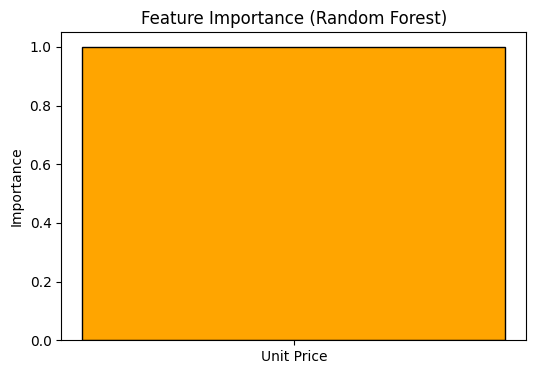

              precision    recall  f1-score   support

           0       0.69      1.00      0.82       692
           1       0.50      0.01      0.02       308

    accuracy                           0.69      1000
   macro avg       0.60      0.50      0.42      1000
weighted avg       0.63      0.69      0.57      1000



In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd

# --- Features and Target ---
# Use numeric predictors (add more if available)
X_cls = df[['Unit Price']].fillna(0)

# Target: Returned (1) vs Not Returned (0)
y_cls = df['Shipping Status'].apply(lambda x: 1 if x=="Returned" else 0)

# --- Fit Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_cls, y_cls)

# Predictions
rf_preds = rf_model.predict(X_cls)
rf_probs = rf_model.predict_proba(X_cls)[:,1]

# --- Dataset Output ---
rf_df = pd.DataFrame({
    "Unit Price": X_cls['Unit Price'],
    "Actual_Return": y_cls,
    "Predicted_Class": rf_preds,
    "Predicted_Probability": rf_probs
})
print(rf_df.head(10))

# --- Graph: Feature Importance ---
importances = rf_model.feature_importances_
plt.figure(figsize=(6,4))
plt.bar(X_cls.columns, importances, color="orange", edgecolor="black")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

# --- Classification Report ---
print(classification_report(y_cls, rf_preds))

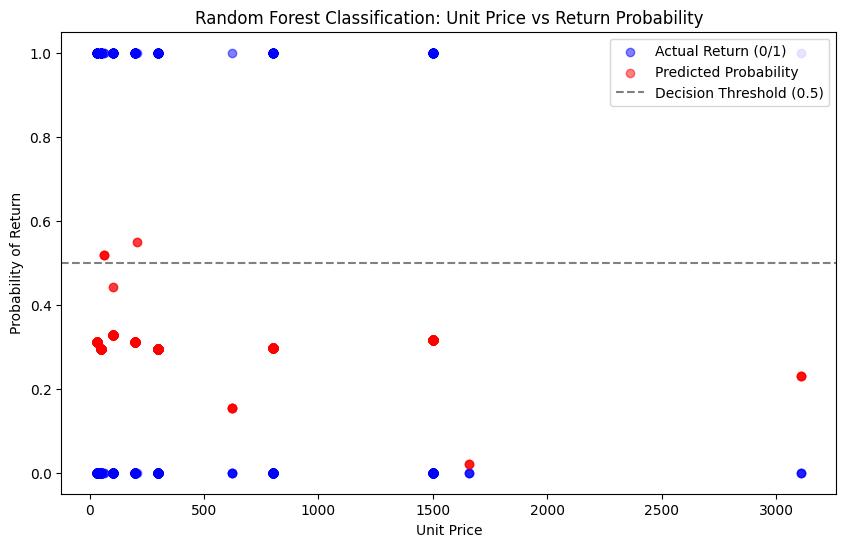

In [39]:
# Predicted probabilities from Random Forest
rf_probs = rf_model.predict_proba(X_cls)[:,1]

plt.figure(figsize=(10,6))
plt.scatter(X_cls['Unit Price'], y_cls, color="blue", alpha=0.5, label="Actual Return (0/1)")
plt.scatter(X_cls['Unit Price'], rf_probs, color="red", alpha=0.5, label="Predicted Probability")
plt.axhline(0.5, color="gray", linestyle="--", label="Decision Threshold (0.5)")
plt.title("Random Forest Classification: Unit Price vs Return Probability")
plt.xlabel("Unit Price")
plt.ylabel("Probability of Return")
plt.legend()
plt.show()